In [5]:
import os
import pandas as pd
import numpy as np
import scipy
from scipy.stats import spearmanr

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib import rc
import seaborn as sns
import Bio.PDB
from scipy import stats
from Bio.PDB import SASA # SASA module won't load from newest version of Biopython for some reason
# import Geometry # Biopython Geometry module still not on main branch

import time
import sys
import glob
sys.path.append('/data/mhoffert/fiererlab/adenylate_kinase_ogt/protein_utils/')
from collections import Counter

import Geometry

from IPython.display import display, clear_output

In [6]:
from __future__ import print_function
import warnings
warnings.filterwarnings('ignore') # make the notebook nicer


# import os
# os.environ['QT_QPA_PLATFORM']='offscreen'

import nglview as nv
import pytraj as pt

print("nglview version = {}".format(nv.__version__))
print("pytraj version = {}".format(pt.__version__))

from Bio.PDB import PDBParser, Select, PDBIO, Polypeptide
from Bio.SeqUtils import seq1

nglview version = 3.1.1
pytraj version = 2.0.6


In [7]:
import IPython

In [8]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [9]:
from utils import read_pfam_table_pandas

In [10]:
from adk_drawer import get_guiding_structures, ss_to_domains, draw_adk, compute_domains

ss_cmap = {'H':'red', 'E':'blue', 'L':'gray'}
domain_cmap = {'core':'red', 'lid':'blue', 'nmp':'green', 'none':'gray', 'ploop':'yellow'}
nglview_list = lambda cmap, residue_ss: [[cmap[r], str(i)] for i, r in enumerate(residue_ss)]

In [ ]:
metrics_df = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240327_metrics_df_filtered.tsv', sep='\t')
metrics_df.head()

In [17]:
secondary_structure = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240327_ss_save.tsv', sep='\t', index_col=0)['secondary_structure']
secondary_structure.head()

genome_id
GB_GCA_000016765.1    LEEEEELLLLLLHHHHHHHHHHHHLLEEEEHHHHHHHHHHLLLHHH...
GB_GCA_000242235.1    LLEEEEEELLLLLLHHHHHHHHHHHHLLLEEEHHHHHHHHHHHLLH...
GB_GCA_000283575.1    LEEEEELLLLLLHHHHHHHHHHHHLLLEEEHHHHHHHHHHLLLHHH...
GB_GCA_000376885.1    LEEEEELLLLLLHHHHHHHHHHHHLLLEEEHHHHHHHHHHLLLHHH...
GB_GCA_000411155.1    LLLEEEEELLLLLLHHHHHHHHHHHHLLLEEEHHHHHHHHHHLLLH...
Name: secondary_structure, dtype: object

In [4]:

uid = 'RS_GCF_004359375.1'

In [54]:
metrics_df.groupby('temp').sample(1)['uid'].values

array(['RS_GCF_018861705.1', 'RS_GCF_000015285.1', 'RS_GCF_018861865.1',
       ..., 'RS_GCF_014646935.1', 'RS_GCF_000018945.1',
       'RS_GCF_000512735.1'], dtype=object)

In [64]:
metrics_df['group'] = pd.cut(metrics_df['mean_temp'], np.linspace(0, 100, 21))

## Actual code

In [195]:
# all_temps = []
for i, uid in enumerate(metrics_df.sort_values('mean_temp', ascending=True)['uid'].values):
    if not uid in core_SASA_test['uid'].unique():
        display(i)
        clear_output(wait=True)
        structure_file = f'/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/processed_structures/{uid}_A_processed.pdb'
        io=Bio.PDB.PDBIO()
        parser = Bio.PDB.PDBParser()
        # get structure
        struct = parser.get_structure(uid, structure_file)
        
        temp_df = pd.DataFrame()
        
        # build queryable protein again
        queryable_protein = []
        for res in Bio.PDB.Selection.unfold_entities(struct, 'R'):
            if Bio.PDB.Polypeptide.is_aa(res, standard=True):
                queryable_protein.append(res)
                
        residues_present = sorted([res.id[1] for res in queryable_protein])
        residues_range = list(range(residues_present[0], residues_present[-1] + 1))
        residues_absent = set(residues_range).difference(residues_present)
        residues_missing_nbrs = residues_absent.union({residues_range[0],residues_range[-1]},{resi+1 for resi in residues_absent},{resi-1 for resi in residues_absent})
            
        # set residue positions as indices for df
        temp_df['Position'] = residues_range
        temp_df = temp_df.set_index('Position')
        
        for chain in Bio.PDB.Selection.unfold_entities(list(queryable_protein), 'C'):
                    if chain.id == 'A':
                        temp_df = temp_df.copy()
                        temp_df['Position'] = temp_df.index
                        #temp_df['chain'] = chain.id
            
                        # calculate contact density
                        contact_cutoffs = [4.5, 1.5]
                        nbr_search = Bio.PDB.NeighborSearch(Bio.PDB.Selection.unfold_entities(chain, 'A'), bucket_size=1000)
                        for cutoff in contact_cutoffs:
                            contacts = nbr_search.search_all(cutoff, 'R')
                            contact_count_dict = {resi: 0 if resi not in residues_absent else np.NaN for resi in temp_df['Position']}
                            for (res1, res2) in contacts:
                                contact_count_dict[res1.id[1]] += 1
                                contact_count_dict[res2.id[1]] += 1
                            temp_df[f'Contacts at {cutoff} Å'] = temp_df['Position'].map(contact_count_dict)
            
                        # solvent exposure - Shrake-Rupley algorithm ("rolling ball" method)
                        sr = SASA.ShrakeRupley(probe_radius=1.40, n_points=1000)
                        sr.compute(struct[0], level="R") # note that this omits burial due to bound ligands or contacts with other chains    
                        temp_df['SASA'] = temp_df['Position'].map(lambda pos: chain[pos].sasa if not pos in residues_absent else np.NaN)
                        temp_df['uid'] = uid
                        temp_df['dom'] = ['C'] + compute_domains(secondary_structure.loc[uid], mm=2)
                        all_temps.append(temp_df)
                        temp_df_m = temp_df.mean(numeric_only=True)
                                    
                        temp_df_m['uid'] = uid
                        # df_collector.append(temp_df_m)
        print(len(all_temps))

KeyboardInterrupt: 

In [196]:
core_SASA_test = pd.concat(all_temps)

In [197]:
idx = pd.IndexSlice
grouped = core_SASA_test.groupby(['uid', 'dom']).mean()

In [205]:
plotdf

,dom,Position,Contacts at 4.5 Å,SASA,Contacts at 1.5 Å
uid,,,,,
GB_GCA_000016765.1,C,118.974359,11.410256,45.030875,1.982906
GB_GCA_000283575.1,C,116.929204,11.477876,46.835113,1.982301
GB_GCA_000423665.1,C,124.500000,11.691667,48.849918,1.983333
GB_GCA_000717275.1,C,103.966292,11.449438,48.364233,1.977528
GB_GCA_001184205.1,C,117.732759,11.715517,45.023086,1.982759
...,...,...,...,...,...
RS_GCF_904848665.1,C,124.943089,11.414634,46.580329,1.983740
RS_GCF_905397275.1,C,125.717742,11.548387,45.646424,1.983871
RS_GCF_905397435.1,C,125.717742,11.620968,46.367682,1.983871


In [215]:
plotdf = grouped.loc[idx[:, 'C'], :].reset_index().set_index('uid')
plotdf = pd.merge(plotdf, metrics_df[['uid', 'mean_temp', 'temp', 'seq_length']], left_index=True, right_on='uid')

In [219]:
args = {'linewidth':0, 'alpha':0.5, 's':15}

<Axes: xlabel='SASA', ylabel='mean_temp'>

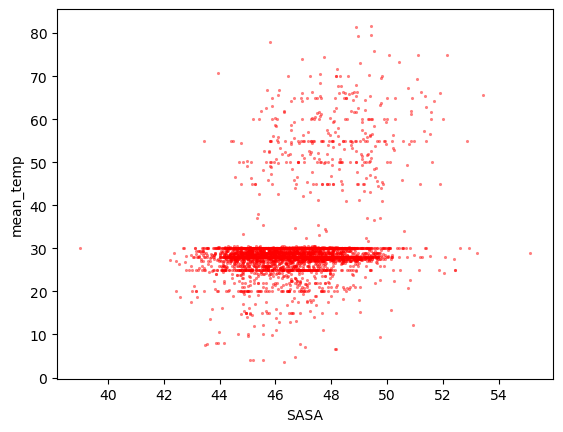

In [227]:
sns.scatterplot(data=plotdf.query('seq_length > 200'), 
                x='SASA',
                y='mean_temp',
                # hue='seq_length',
                color='red',
                **args
            )

# sns.kdeplot(x=plotdf['SASA'],
#                 y=plotdf['temp'],
#             bins=25)

<Axes: xlabel='Contacts at 4.5 Å', ylabel='mean_temp'>

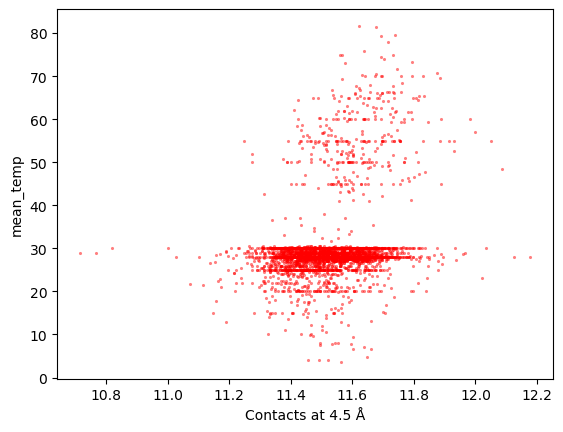

In [229]:
sns.scatterplot(data=plotdf.query('seq_length > 200'), 
                x='Contacts at 4.5 Å',
                y='mean_temp',
                # hue='seq_length',
                color='red',
                **args
            )

In [211]:
spearmanr(plotdf.query('seq_length > 200')['SASA'],
          plotdf.query('seq_length > 200')['temp'])

SignificanceResult(statistic=0.19109881799033812, pvalue=2.9040196855267497e-33)

In [201]:
plotdf

,dom,Position,Contacts at 4.5 Å,SASA,Contacts at 1.5 Å
uid,,,,,
GB_GCA_000016765.1,C,118.974359,11.410256,45.030875,1.982906
GB_GCA_000283575.1,C,116.929204,11.477876,46.835113,1.982301
GB_GCA_000423665.1,C,124.500000,11.691667,48.849918,1.983333
GB_GCA_000717275.1,C,103.966292,11.449438,48.364233,1.977528
GB_GCA_001184205.1,C,117.732759,11.715517,45.023086,1.982759
...,...,...,...,...,...
RS_GCF_904848665.1,C,124.943089,11.414634,46.580329,1.983740
RS_GCF_905397275.1,C,125.717742,11.548387,45.646424,1.983871
RS_GCF_905397435.1,C,125.717742,11.620968,46.367682,1.983871


In [194]:
len(plotdf)

883

In [140]:
genome = 'RS_GCF_000315055.1'
file = f'{genome}_closed.pdb'
struct_path = '/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/test_structures/'

draw_adk(f'{struct_path}{file}', color_ss=ss_cmap, ss=secondary_structure.loc[genome])

NGLWidget()

<Axes: xlabel='SASA', ylabel='temp'>

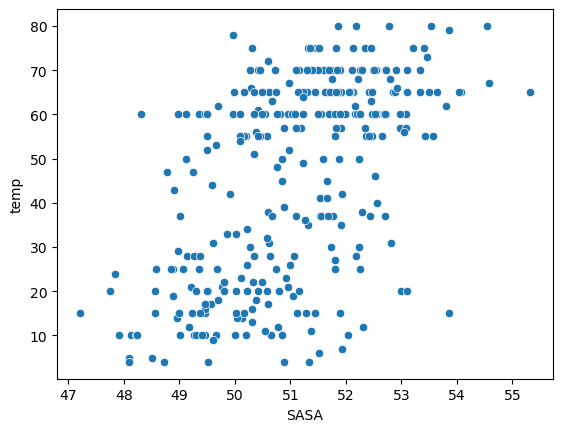

In [174]:
sns.scatterplot(data=metrics_df.set_index('uid').reindex(plotdf.index),
                x='SASA', y='temp')

In [175]:
spearmanr(metrics_df.set_index('uid').reindex(plotdf.index)['SASA'],
         metrics_df.set_index('uid').reindex(plotdf.index)['temp'])

SignificanceResult(statistic=0.5269739439647406, pvalue=1.7666847478028238e-24)

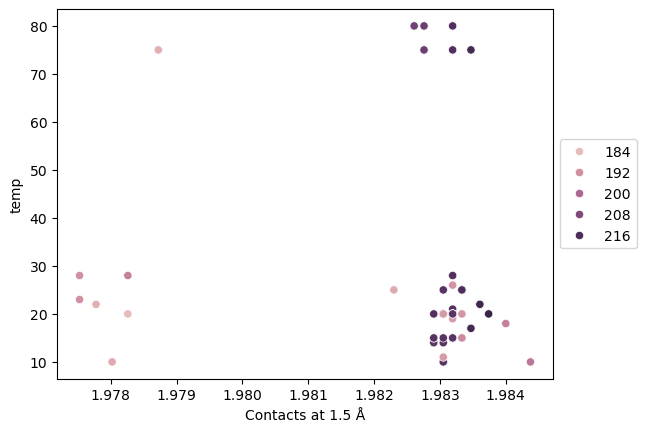

In [145]:
sns.scatterplot(x=plotdf['Contacts at 1.5 Å'],
                y=metrics_df.set_index('uid').reindex(plotdf.index)['temp'],
                hue=metrics_df.set_index('uid').reindex(plotdf.index)['seq_length'])
lgd = plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

<Axes: xlabel='dom', ylabel='Contacts at 4.5 Å'>

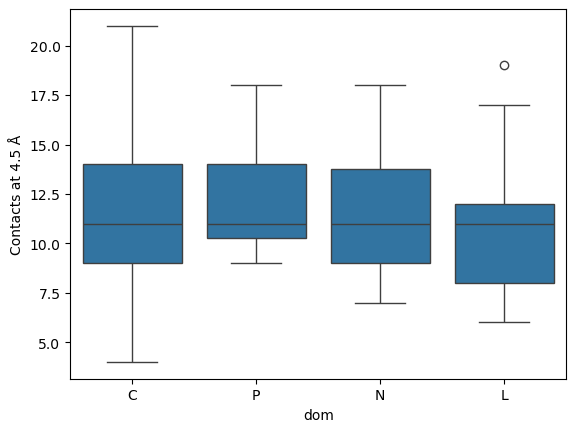

In [26]:
sns.boxplot(data=temp_df, x='dom', y='Contacts at 4.5 Å')

<Axes: xlabel='dom', ylabel='SASA'>

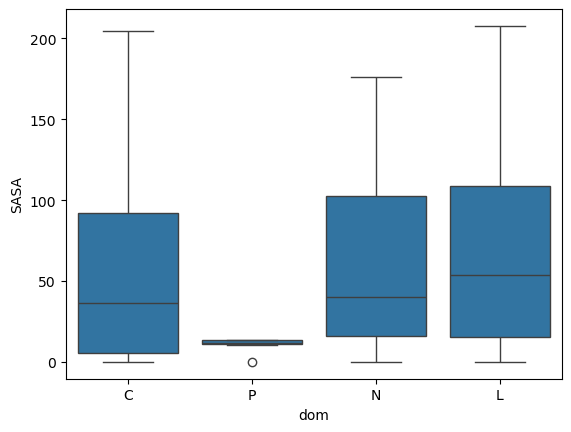

In [27]:
sns.boxplot(data=temp_df, x='dom', y='SASA')

## Test 5/20/24

In [86]:
import subprocess

def get_lid(hmm_model, sequence_file):
    

    # Run hmmscan command
    p = subprocess.run(['hmmsearch', '-o', '/dev/null', '--domtblout', '/dev/stdout', hmm_model, sequence_file], 
                       capture_output=True, text=True)
    # parse hit lines
    evals = []
    for i, line in enumerate(p.stdout.split('\n')[:-1]):
        if line.startswith('#'):
            continue
        else:
            fields = line.split()
            evals.append((fields[13], fields[17], fields[18]))
        
    if len(evals) > 0:
        sorted_evals = sorted(evals, key=lambda x: x[0])
        return [int(i) for i in sorted_evals[-1][1:]]
    else:
        return [-1, -1]

In [87]:
test_metrics = pd.read_csv('./../data/test_mp.tsv', sep='\t')

In [88]:
hmm = '/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/PF05191/PF05191.hmm'
adk_base = '/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/adks/'


lid_locs = pd.DataFrame(index=test_metrics['uid'].unique(), columns=['lid_start', 'lid_stop'],
             data=[get_lid(hmm, f'{adk_base}{uid}_adk.faa') for uid in test_metrics['uid'].unique()])
lid_locs

,lid_start,lid_stop
GB_GCA_000376885.1,-1,-1
GB_GCA_000016765.1,127,163
GB_GCA_000242235.1,141,176
GB_GCA_000283575.1,123,158
GB_GCA_001054945.1,-1,-1


In [89]:
test_metrics['lid'] = test_metrics.apply(lambda row: (row['Position'] >= lid_locs.loc[row['uid'], 'lid_start']) &
                   (row['Position'] <= lid_locs.loc[row['uid'], 'lid_stop']), axis=1)

In [90]:
# add lid/nonlid column
test_metrics

,Position,Contacts at 4.5 Å,SASA,uid,lid
0,1,10,68.143124,GB_GCA_000376885.1,False
1,2,15,38.130233,GB_GCA_000376885.1,False
2,3,16,0.084949,GB_GCA_000376885.1,False
3,4,15,0.000000,GB_GCA_000376885.1,False
4,5,16,0.192095,GB_GCA_000376885.1,False
...,...,...,...,...,...
1002,177,9,76.701985,GB_GCA_001054945.1,False
1003,178,10,14.865710,GB_GCA_001054945.1,False
1004,179,14,19.403240,GB_GCA_001054945.1,False
1005,180,5,124.666258,GB_GCA_001054945.1,False


In [92]:
genome = 'GB_GCA_001054945.1'
pdb = f'/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/processed_structures/{genome}_A_processed.pdb'
traj = pt.load(pdb)
w = nv.show_pytraj(traj, default_representation=False)
w.add_cartoon(color='gray')

lid_positions = test_metrics[test_metrics.uid.eq(f'{genome}')].set_index('Position')['lid']
ss = ['lid' if l else 'nonlid' for l in lid_positions.values]
    
colors = nglview_list({'lid':'yellow', 'nonlid':'gray'}, ss)

scheme = nv.color._ColorScheme(colors, label='secondary structure')

w.add_cartoon(color=scheme)

w

NGLWidget()

In [94]:
print(type([1,]))

<class 'list'>
